## 🏷️OBJETIVO DEL PRESENTE CUADERNO (PREPROCESAMIENTO)

💡 ¿Para qué sirve este cuaderno y cuál es su funcionamiento?
Imaginemos que nuestro proyecto es una fábrica de galletas.

En el Cuaderno preprocesamiento, construiremos una máquina moldeadora personalizada (la variable: aduana_datos). Esta máquina agarra los ingredientes crudos del cliente y los estira y corta de forma perfecta para que queden con el tamaño exacto que exige el horno.

En el Cuaderno modeldo, ahí tenemos el horno industrial (los modelos predictivos). El horno solo acepta moldes exactos de columnas. Si metemos algo deforme, se quema.

La App de Streamlit es una sucursal nueva de la fábrica que montaremos en la web. Cuando un cliente use la App, meterá sus datos en crudo. La App necesitará usar exactamente la misma máquina moldeadora que construiremos en el presente cuaderno para procesar los datos antes de meterlos al horno.

¿Cuál va a ser el problema una cez hecha la máquina moldeadora?

La máquina moldeadora (aduana_datos) vive únicamente en la memoria RAM del ordenador mientras este abierto el Cuaderno preprocesamiento. Si cerramos el cuaderno o apagamos el ordenador, la máquina desaparece.

Para que la App de Streamlit pueda usarla en el futuro, tenemos que "congelar" esa máquina y guardarla en un archivo físico en el disco duro (un archivo .pkl). A este proceso lo llamaremos "serialización", es simplemente guardar la máquina en una caja para poder llevarla a la App.

Una vez guardada la maquina moldeadora, pasamos a guardar materia prima para los hornos del cuaderno de modelado,  ya procesada

## 🔧 Preparación del Entorno e Importación de Librerías

In [27]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuración de salida y reproducibilidad
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
SEED = 42
np.random.seed(SEED)

print("✅ Entorno de Preprocesamiento listo.")

✅ Entorno de Preprocesamiento listo.


## 🛠️ Gestión de Rutas y Carga de Datos

In [28]:
# 1. Definición de la ruta del Tablón Maestro Certificado
PROCESSED_MASTER_PATH = r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\data\processed\ecommerce_master_tablon.csv"

if not os.path.exists(PROCESSED_MASTER_PATH):
    raise FileNotFoundError(f"No se encontró el tablón maestro en: {PROCESSED_MASTER_PATH}")

# 2. Carga directa de la materia prima refinada
df_saneado = pd.read_csv(PROCESSED_MASTER_PATH)

print(f"📊 Dataset de producción cargado directamente: {df_saneado.shape[0]:,} filas × {df_saneado.shape[1]} columnas.")
print("💡 Nota: Datos verificados del EDA. Listos para la Fase de Partición (Train/Test) y Aduana.")

📊 Dataset de producción cargado directamente: 100,000 filas × 31 columnas.
💡 Nota: Datos verificados del EDA. Listos para la Fase de Partición (Train/Test) y Aduana.


## 🛠️ Auditoría de Calidad de Datos (Data Quality Framework):

Nota importnte: nunca se empieza a transformar un dataset unificado sin antes realizar una auditoría de calidad de datos de entrada (Data Quality Audit).

In [29]:
# =====================================================================
# DETECCIÓN DE CALIDAD AVANZADA POST-SANEAMIENTO
# =====================================================================

def auditoria_calidad_datos_avanzada(df_evaluación):
    """
    Diagnóstico integral de calidad. Evalúa nulos, tipos de datos,
    métricas de dispersión, outliers por IQR y duplicados globales.
    """
    # 1. Cálculos de duplicados a nivel general
    total_filas = len(df_evaluación)
    total_duplicados = df_evaluación.duplicated().sum()
    
    print("="*75)
    print("🔬 REPORTE AVANZADO DE CALIDAD DE DATOS (DATA QUALITY AUDIT)")
    print("="*75)
    print(f"📈 Dimensiones actuales : {total_filas:,} filas | {df_evaluación.shape[1]} columnas")
    print(f"🔁 Duplicados globales  : {total_duplicados:,} filas detectadas en el set de evaluación")
    print("="*75)
    
    reporte_columnas = []
    
    for col in df_evaluación.columns:
        valores_nulos = df_evaluación[col].isna().sum()
        porcentaje_nulos = (valores_nulos / total_filas) * 100
        valores_unicos = df_evaluación[col].nunique()
        tipo_dato = df_evaluación[col].dtype
        
        media, mediana, minimo, maximo, q25, q75, flag_outliers = "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"
        
        if np.issubdtype(tipo_dato, np.number):
            media = df_evaluación[col].mean()
            mediana = df_evaluación[col].median()
            minimo = df_evaluación[col].min()
            maximo = df_evaluación[col].max()
            q25 = df_evaluación[col].quantile(0.25)
            q75 = df_evaluación[col].quantile(0.75)
            
            # Criterio estadístico IQR para Outliers
            iqr = q75 - q25
            limite_inferior = q25 - 1.5 * iqr
            limite_superior = q75 + 1.5 * iqr
            
            outliers_count = df_evaluación[(df_evaluación[col] < limite_inferior) | (df_evaluación[col] > limite_superior)][col].count()
            flag_outliers = f"Sí ({outliers_count:,})" if outliers_count > 0 else "No"
        
        ejemplo_valores = df_evaluación[col].dropna().unique()[:3].tolist()
        
        reporte_columnas.append({
            'Columna': col,
            'Tipo': str(tipo_dato),
            'Nulos (Cant.)': valores_nulos,
            'Nulos (%)': porcentaje_nulos,
            'Valores Únicos': valores_unicos,
            'Media': media,
            'Mediana': mediana,
            'Mínimo': minimo,
            'Máximo': maximo,
            'Q25': q25,
            'Q75': q75,
            '¿Tiene Outliers?': flag_outliers,
            'Ejemplos': ejemplo_valores
        })
    
    df_reporte = pd.DataFrame(reporte_columnas)
    return df_reporte

# Lanzamos el diagnóstico definitivo sobre el dataframe ya higienizado
reporte_final = auditoria_calidad_datos_avanzada(df_saneado)
reporte_final.sort_values(by='Nulos (%)', ascending=False)

🔬 REPORTE AVANZADO DE CALIDAD DE DATOS (DATA QUALITY AUDIT)
📈 Dimensiones actuales : 100,000 filas | 31 columnas
🔁 Duplicados globales  : 0 filas detectadas en el set de evaluación


,Columna,Tipo,Nulos (Cant.),Nulos (%),Valores Únicos,Media,Mediana,Mínimo,Máximo,Q25,Q75,¿Tiene Outliers?,Ejemplos
26,rating_avg,float64,11615,11.6150,21,4.0945,4.1000,1.0000,5.0000,3.9000,4.3000,"Sí (13,536)","[4.2, 2.5, 4.5]"
1,user_id,object,0,0.0000,6944,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[8a49a58e-7e31-4616-8ac8-b1472ed4f5d8, 1a79b3a..."
0,interaction_id,object,0,0.0000,100000,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[2ece1c7b-3244-4eeb-8d3e-f1b0cc09f20f, bef097f..."
3,session_id,object,0,0.0000,19315,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[0003375f-8f69-44e1-9429-ec083de18495, 0003761..."
4,interaction_type,object,0,0.0000,6,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[view, add_to_wishlist, remove_from_wishlist]"
5,timestamp,object,0,0.0000,96257,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[2025-03-13 08:29:18.000000832, 2025-03-13 08:..."
2,product_id,object,0,0.0000,967,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[d3701c21-709a-4090-bab2-020261ce8a92, b1a8533..."
7,user_id_sesion,object,0,0.0000,6944,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[8a49a58e-7e31-4616-8ac8-b1472ed4f5d8, 1a79b3a..."
8,start_time,object,0,0.0000,19315,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[2025-03-13 08:29:18.000000832, 2026-05-07 16:..."
9,device_type,object,0,0.0000,3,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[mobile, desktop, tablet]"


## 🏷️ PURGA DE METADATOS (REDUCCIÓN DE DIMENSIONALIDAD INICIAL ) Y CLASIFICACIÓN AUTOMATIZADA DE PREDICTORES 

In [30]:
# =====================================================================
# FASE 1: PURGA DE METADATOS Y CLASIFICACIÓN AUTOMATIZADA DE PREDICTORES
# =====================================================================

# 1. Definición defensiva de columnas a descartar (IDs y textos libres)
# 🔍 NOTA: Ahora van en minúsculas porque df_saneado ya las estandarizó.
columnas_a_descartar = [
    'interaction_id', 'user_id', 'product_id', 'session_id', 'user_id_sesion',
    'product_name', 'product_description',
    'timestamp', 'start_time', 'signup_date', 'date_added',
    'dwell_time_ms'
]

# 2. Limpieza de metadatos utilizando el DataFrame SANEADO e HIGIENIZADO
df_filtrado = df_saneado.drop(columns=[col for col in columnas_a_descartar if col in df_saneado.columns])

# 3. Aislamiento del Target (También en minúsculas)
TARGET = 'is_converted'
X = df_filtrado.drop(columns=[TARGET])
y = df_filtrado[TARGET]

# 4. El Split Sagrado (80% Train / 20% Test) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 5. DETECCIÓN AUTOMÁTICA Y GENÉRICA POR TIPO TÉCNICO
variables_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# 6. REPORTE DE INFRAESTRUCTURA METODOLÓGICA
print("="*60)
print("🔬 REPORT DE ESTRUCTURA METODOLÓGICA (FASE 1)")
print("="*60)
print(f"📈 Matriz de Entrenamiento (X_train): {X_train.shape[0]:,} filas y {X_train.shape[1]} predictores.")
print(f"📈 Matriz de Prueba        (X_test) : {X_test.shape[0]:,} filas y {X_test.shape[1]} predictores.")
print(f"🎯 Variable Objetivo       (Target) : '{TARGET}' ({y_train.dtype})")
print(f"   └─ Balance en Train: {y_train.value_counts(normalize=True).to_dict()}")
print("="*60)

print(f"🔢 VARIABLES NUMÉRICAS DETECTADAS ({len(variables_numericas)}):")
print("-" * 60)
for idx, col in enumerate(variables_numericas, 1):
    print(f" [{idx:02d}] Column: '{col}' -> Tipo técnico: {X_train[col].dtype}")

print("\n🔤 VARIABLES CATEGÓRICAS DETECTADAS ({len(variables_categoricas)}):")
print("-" * 60)
for idx, col in enumerate(variables_categoricas, 1):
    print(f" [{idx:02d}] Column: '{col}' -> Tipo técnico: {X_train[col].dtype}")
print("="*60)

🔬 REPORT DE ESTRUCTURA METODOLÓGICA (FASE 1)
📈 Matriz de Entrenamiento (X_train): 80,000 filas y 18 predictores.
📈 Matriz de Prueba        (X_test) : 20,000 filas y 18 predictores.
🎯 Variable Objetivo       (Target) : 'is_converted' (bool)
   └─ Balance en Train: {False: 0.8905, True: 0.1095}
🔢 VARIABLES NUMÉRICAS DETECTADAS (6):
------------------------------------------------------------
 [01] Column: 'age' -> Tipo técnico: int64
 [02] Column: 'price' -> Tipo técnico: float64
 [03] Column: 'rating_avg' -> Tipo técnico: float64
 [04] Column: 'review_count' -> Tipo técnico: int64
 [05] Column: 'stock_quantity' -> Tipo técnico: int64
 [06] Column: 'dwell_time_secs' -> Tipo técnico: float64

🔤 VARIABLES CATEGÓRICAS DETECTADAS ({len(variables_categoricas)}):
------------------------------------------------------------
 [01] Column: 'interaction_type' -> Tipo técnico: object
 [02] Column: 'device_type' -> Tipo técnico: object
 [03] Column: 'referrer_source' -> Tipo técnico: object
 [04] Co

## 🧑‍💻 Fase 2: Imputación Inteligente por Categoría

🗺️ ¿En qué etapa del proyecto estamos y hacia dónde vamos?
Estamos en la fase de Preprocesamiento de Datos (o Data Preparation).

- El objetivo de esta etapa: Dejar las matrices de datos (X_train y X_test) impecables, en formato 100% numérico y sin un solo vacío, para que los modelos de Machine Learning puedan procesarlas sin lanzar errores matemáticos.

- Hacia dónde vamos: Una vez que terminemos de limpiar y transformar las variables (en los siguientes pasos escalaremos los números y codificaremos los textos), pasaremos directamente a la Fase de Modelado, donde la Inteligación Artificial leerá estos datos limpios para aprender a predecir si un cliente va a comprar o no (is_converted).

🎯 ¿Cuál es el objeto de este script específico?
El objeto del script es neutralizar los valores nulos (NaN) de la columna rating_avg de forma realista y segura.

Como tu auditoría inicial detectó que más de la mitad de los productos no tenían calificación, teníamos que rellenar esos huecos. El script hace una imputación condicionada por contexto: en lugar de inventar una nota promedio para todo el e-commerce, el código va departamento por departamento.
Si a un artículo de Automotive (Automoción) le falta su calificación, el script mira el comportamiento de su propio grupo y le asigna un 4.70. En cambio, si el producto es un libro (Books), le asigna un 3.90. Esto refleja la realidad comercial del catálogo.

In [31]:
# =====================================================================
# FASE 2: IMPUTACIÓN INTELIGENTE DE NULOS (REVISIÓN DE INGENIERÍA)
# =====================================================================

def ejecutar_imputacion_inteligente(X_train_df, X_test_df, col_agrupadora, col_a_imputar):
    """
    Función empaquetada para rellenar nulos de forma quirúrgica.
    Usa una columna 'guía' (col_agrupadora) para reparar la columna 'dañada' (col_a_imputar).
    """
    # PASO A: Creamos copias exactas en la memoria de Python.
    # Esto se hace para que Pandas no nos llance una advertencia (Warning) de que estamos
    # alterando los datos originales sin permiso.
    X_train_out = X_train_df.copy()
    X_test_out = X_test_df.copy()
    
    # PASO B: Contamos cuántos nulos hay en este preciso instante antes de empezar.
    # Guardamos el número en una variable para el reporte final.
    nulos_train_inicial = X_train_out[col_a_imputar].isna().sum()
    nulos_test_inicial = X_test_out[col_a_imputar].isna().sum()
    
    # PASO C: LA BRÚJULA ESTADÍSTICA (Calculada SOLO con el 80% de Train)
    # .groupby(col_agrupadora) -> Junta los datos por 'category' (crea grupos de Electronics, Books, etc.)
    # [col_a_imputar].median() -> De cada grupo, calcula la MEDIANA de su 'rating_avg'
    # Esto genera un diccionario/mapa mental. Ej: {'Books': 3.90, 'Electronics': 4.10}
    medianas_por_categoria = X_train_out.groupby(col_agrupadora)[col_a_imputar].median()
    
    # Red de seguridad: Calculamos la mediana de TODA la columna por si acaso en el set
    # de Test aparece una categoría nueva que no existía en Train.
    mediana_global_train = X_train_out[col_a_imputar].median()
    
    # PASO D: EL ALGORITMO DE ASIGNACIÓN (La regla que se aplica a cada fila)
    def rellenar_vacio(fila, mapa_medianas, respaldo_global):
        # 1. Si la celda de la columna (rating_avg) NO es nula, no hacemos nada, devolvemos su valor real.
        if not pd.isna(fila[col_a_imputar]):
            return fila[col_a_imputar]
        
        # 2. Si la celda SÍ es nula (NaN), extraemos la categoría de esa fila (ej: 'Books')
        categoria_de_la_fila = fila[col_agrupadora]
        
        # 3. Buscamos en nuestro mapa si tenemos la mediana para 'Books'
        # .get() busca la categoría; si no la encuentra, usa el 'respaldo_global'
        mediana_asignada = mapa_medianas.get(categoria_de_la_fila, respaldo_global)
        
        return mediana_asignada
    
    # PASO E: EJECUCIÓN (Pasar la regla fila por fila)
    # .apply(..., axis=1) significa: 'recorre el dataframe fila por fila horizontalmente'
    # Ejecutamos la regla tanto en el set de Entrenamiento como en el de Pruebas.
    X_train_out[col_a_imputar] = X_train_out.apply(
        lambda row: rellenar_vacio(row, medianas_por_categoria, Wood_respaldo := mediana_global_train), axis=1
    )
    X_test_out[col_a_imputar] = X_test_out.apply(
        lambda row: rellenar_vacio(row, medianas_por_categoria, mediana_global_train), axis=1
    )
    
    # PASO F: REPORTE PARA EL USUARIO
    # Imprime la auditoría final en pantalla para que el ingeniero verifique el éxito del proceso.
    print("="*60)
    print(f"🔬 REPORTE DE IMPUTACIÓN ANALÍTICA: '{col_a_imputar}'")
    print("="*60)
    print(f"📊 Nulos corregidos en X_train : {nulos_train_inicial:,} -> {X_train_out[col_a_imputar].isna().sum()}")
    print(f"📊 Nulos corregidos en X_test  : {nulos_test_inicial:,} -> {X_test_out[col_a_imputar].isna().sum()}")
    print("="*60)
    print("📌 Mapeo de medianas por categoría calculadas en Train:")
    for cat, val in medianas_por_categoria.items():
        print(f"   └─ Categoría: '{cat}' ➔ Mediana Aplicada: {val:.2f}")
    print("="*60)
    
    # Devolvemos los nuevos DataFrames ya reparados y listos
    return X_train_out, X_test_out

# Ejecución controlada usando tus variables exactas en minúsculas
X_train, X_test = ejecutar_imputacion_inteligente(
    X_train_df=X_train, 
    X_test_df=X_test, 
    col_agrupadora='category', 
    col_a_imputar='rating_avg'
)

🔬 REPORTE DE IMPUTACIÓN ANALÍTICA: 'rating_avg'
📊 Nulos corregidos en X_train : 9,230 -> 0
📊 Nulos corregidos en X_test  : 2,385 -> 0
📌 Mapeo de medianas por categoría calculadas en Train:
   └─ Categoría: 'Automotive' ➔ Mediana Aplicada: 4.70
   └─ Categoría: 'Beauty & Personal Care' ➔ Mediana Aplicada: 4.30
   └─ Categoría: 'Books' ➔ Mediana Aplicada: 3.90
   └─ Categoría: 'Clothing & Accessories' ➔ Mediana Aplicada: 3.90
   └─ Categoría: 'Electronics' ➔ Mediana Aplicada: 4.10
   └─ Categoría: 'Grocery & Gourmet' ➔ Mediana Aplicada: 4.00
   └─ Categoría: 'Home & Kitchen' ➔ Mediana Aplicada: 4.20
   └─ Categoría: 'Office Products' ➔ Mediana Aplicada: 4.10
   └─ Categoría: 'Sports & Outdoors' ➔ Mediana Aplicada: 4.00
   └─ Categoría: 'Toys & Games' ➔ Mediana Aplicada: 4.50


📊 ¿Por qué usamos la MEDIANA en vez de la MEDIA (Promedio)?
La razón es puramente estadística: la media es sumamente sensible a los valores extremos (outliers), mientras que la mediana es inmune a ellos.

Imaginemos que en la categoría de Electronics tenemos 5 productos con las siguientes calificaciones:
[1.0, 4.5, 4.7, 4.8, 5.0] (el 1.0 puede ser un producto defectuoso o una reseña malintencionada).

- Si calculamos la Media (Promedio): Sumamos todo y dividimos entre 5. El resultado es 4.00. Ese único 1.0 arrastró y bajó el promedio de toda la categoría, haciendo parecer que la electrónica es peor de lo que realmente es.

- Si calculamos la Mediana: Ordenamos los números de menor a mayor y tomamos el valor que se encuentra exactamente en el centro. El valor central es 4.70.

💡 Conclusión: La mediana representa mucho mejor al "producto típico" de una categoría porque ignora los extremos atípicos. Por eso, en analítica de datos, para rellenar nulos siempre se prefiere la mediana.

🛡️ El concepto clave: ¿Qué es el "Anti-Data Leakage" (Fuga de Datos)?
Si miramos el reporte, el script dice:

Nulos corregidos en X_train: 9,230 -> 0

Nulos corregidos en X_test: 2,385 -> 0

El script calculó las medianas de las categorías utilizando únicamente las 80,000 filas de X_train. El conjunto de examen (X_test) se quedó cerrado bajo llave. Una vez calculadas las medianas (por ejemplo, el 4.10 para Electronics), usamos ese dato para rellenar tanto los vacíos de Train como los de Test.

Si hubiésemos usado todo el dataset completo antes del split para calcular las medianas, la información del conjunto de prueba habría "contaminado" el entrenamiento. Eso es el Data Leakage. Al hacerlo como lo hicimos, garantizamos un modelo honesto que cuando sea evaluado con el set de Test, se enfrentará a datos verdaderamente desconocidos.

## 🛠️ Diagnóstico Genérico y Automatizado: Su única función es analizar, medir y pintar el estado real de los datos antes de tocarlos.

👨‍🏫 Guía para Interpretar Resultados
Pruebas irrefutables:

A. La Evidencia Gráfica (idioma visual)
En el Histograma (Izquierda): Si vemos que los datos se amontonan a la izquierda y dejan una "rampa" larga hacia la derecha (como sucede habitualmente con price o dwell_time_secs), estámos ante una curva asimétrica.

En el Q-Q Plot (Derecha): Para que una variable sea Normal, los puntos rojos deben seguir estrictamente la línea recta diagonal. Si los puntos se curvan en los extremos formando una "S" o una parábola, la matemática demuestra que la variable tiene colas pesadas u outliers destructivos.

B. Los Indicadores Clave del Resumen Ejecutivo (Los Hechos)
Skewness (Asimetría): Una variable perfectamente normal tiene 0. Si la variable supera el +1.0 o -1.0, el sesgo es severo.

Kurtosis (Apuntamiento): Mide la concentración de datos en la media y el peso de las colas. Si es muy alta (mayor a 3), significa que la variable produce outliers extremos con mucha frecuencia (distribución leptocúrtica).

🛡️ AUDITORÍA DE NORMALIDAD Y DIAGNÓSTICO DE SESGO AUTOMATIZADO
📊 Variables identificadas para auditoría: ['age', 'price', 'rating_avg', 'review_count', 'stock_quantity', 'dwell_time_secs']



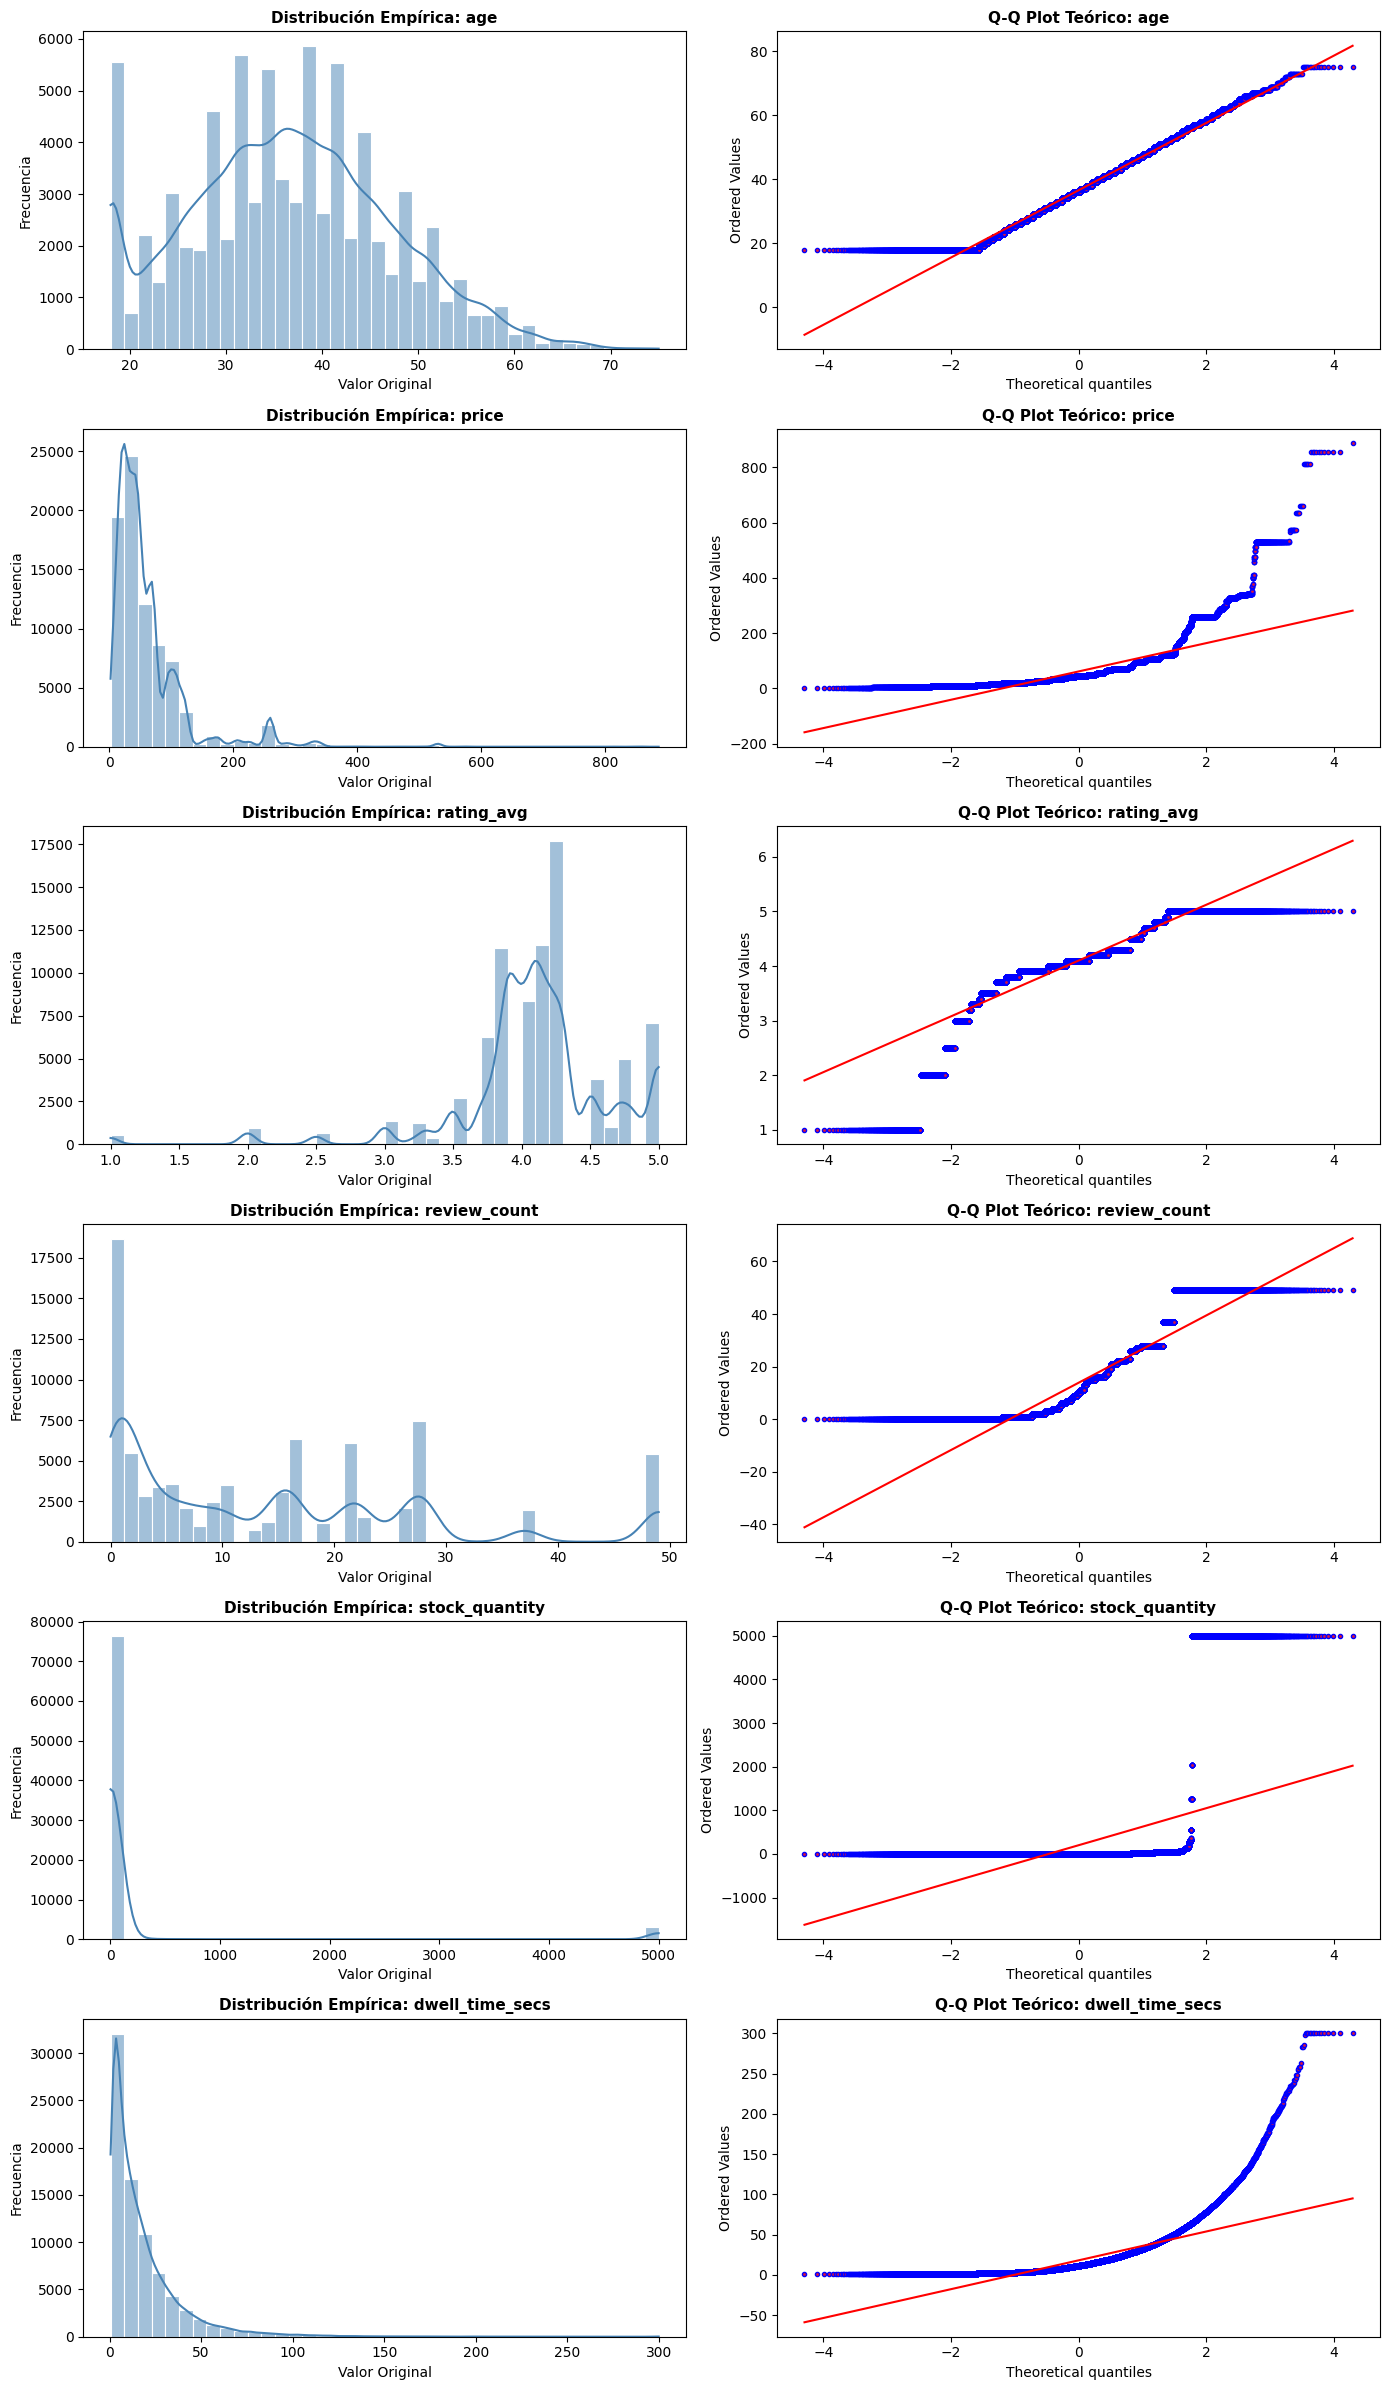


🏛️ RESUMEN EJECUTIVO: CUADRO DE MANDO DE DISTRIBUCIONES
       Variable  Skewness (Asimetría)  Kurtosis (Apuntamiento)  p-value (D'Agostino) Estado Formal          Diagnóstico de Perfil
            age               0.22973                 -0.32582               0.00000   ❌ NO NORMAL          Simétrica (Aceptable)
          price               3.40341                 18.22265               0.00000   ❌ NO NORMAL Asimetría Derecha (Cola Larga)
     rating_avg              -1.71551                  7.40723               0.00000   ❌ NO NORMAL            Asimetría Izquierda
   review_count               1.06034                  0.42154               0.00000   ❌ NO NORMAL Asimetría Derecha (Cola Larga)
 stock_quantity               4.82289                 21.29422               0.00000   ❌ NO NORMAL Asimetría Derecha (Cola Larga)
dwell_time_secs               3.43911                 21.21527               0.00000   ❌ NO NORMAL Asimetría Derecha (Cola Larga)
💡 Criterio Directivo: Cualquier v

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

print("=" * 80)
print("🛡️ AUDITORÍA DE NORMALIDAD Y DIAGNÓSTICO DE SESGO AUTOMATIZADO")
print("=" * 80)

# 1. FILTRADO AUTOMÁTICO DE VARIABLES CUANTITATIVAS
# El script detecta por sí solo qué columnas son numéricas en tu DataFrame X_train
variables_numericas = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"📊 Variables identificadas para auditoría: {variables_numericas}\n")

# 2. CONFIGURACIÓN DEL LIENZO DINÁMICO
# Creamos una cuadrícula de gráficos adaptativa según el número de variables detectadas
num_vars = len(variables_numericas)
fig, axes = plt.subplots(num_vars, 2, figsize=(14, 4 * num_vars))

# Forzamos que axes sea una matriz bidimensional incluso si solo hay una variable
if num_vars == 1:
    axes = np.expand_dims(axes, axis=0)

# Contenedor para el Resumen Ejecutivo final
reporte_datos = []

# =====================================================================
# 3. BUCLE DE AUDITORÍA MATEMÁTICA Y GRÁFICA
# =====================================================================
for i, col in enumerate(variables_numericas):
    # Extracción de datos limpios (eliminando NaNs temporales si los hubiera para el cálculo)
    datos_vivos = X_train[col].dropna()

    # --- COLUMNA GRAPH 1: HISTOGRAMA + DENSIDAD ---
    sns.histplot(
        datos_vivos,
        kde=True,
        ax=axes[i, 0],
        color="steelblue",
        edgecolor="white",
        bins=40,
    )
    axes[i, 0].set_title(
        f"Distribución Empírica: {col}", fontweight="bold", fontsize=11
    )
    axes[i, 0].set_xlabel("Valor Original")
    axes[i, 0].set_ylabel("Frecuencia")

    # --- COLUMNA GRAPH 2: Q-Q PLOT PRO ---
    # Compara los cuantiles reales de tus datos contra los cuantiles teóricos de una Normal
    stats.probplot(datos_vivos, dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"Q-Q Plot Teórico: {col}", fontweight="bold", fontsize=11)
    axes[i, 1].get_lines()[0].set_markerfacecolor("crimson")
    axes[i, 1].get_lines()[0].set_markersize(3)

    # --- CÁLCULOS ESTADÍSTICOS DE GOBIERNO ---
    skewness = stats.skew(datos_vivos)
    kurtosis = stats.kurtosis(
        datos_vivos
    )  # Kurtosis de Fisher (Normal pura = 0)

    # Test de D'Agostino-Pearson (Prueba ómibus de normalidad)
    # H0: Los datos provienen de una distribución normal.
    # Si p-value < 0.05, rechazamos H0 con un 95% de confianza.
    stat_test, p_val = stats.normaltest(datos_vivos)
    veredicto_estadistico = "❌ NO NORMAL" if p_val < 0.05 else "✅ NORMAL"

    # Clasificación formal del sesgo para el negocio
    if abs(skewness) < 0.5:
        tipo_sesgo = "Simétrica (Aceptable)"
    elif skewness >= 0.5:
        tipo_sesgo = "Asimetría Derecha (Cola Larga)"
    else:
        tipo_sesgo = "Asimetría Izquierda"

    # Alimentamos el reporte corporativo
    reporte_datos.append(
        {
            "Variable": col,
            "Skewness (Asimetría)": skewness,
            "Kurtosis (Apuntamiento)": kurtosis,
            "p-value (D'Agostino)": p_val,
            "Estado Formal": veredicto_estadistico,
            "Diagnóstico de Perfil": tipo_sesgo,
        }
    )

plt.tight_layout()
plt.show()

# =====================================================================
# 4. COMPILACIÓN DEL RESUMEN EJECUTIVO DE GOBIERNO
# =====================================================================
print("\n" + "=" * 80)
print("🏛️ RESUMEN EJECUTIVO: CUADRO DE MANDO DE DISTRIBUCIONES")
print("=" * 80)

df_reporte = pd.DataFrame(reporte_datos)
# Formateamos los floats para que el p-value no salga en notación científica incomprensible
pd.options.display.float_format = "{:,.5f}".format
print(df_reporte.to_string(index=False))

print("=" * 80)
print(
    "💡 Criterio Directivo: Cualquier variable con '❌ NO NORMAL' y Skewness > |1.0|"
)
print(
    "   está inyectando ruido/distorsión a los coeficientes de la Regresión Logística."
)
print("=" * 80)

Recordemos

B. Los Indicadores Clave del Resumen Ejecutivo (Los Hechos)
Skewness (Asimetría): Una variable perfectamente normal tiene 0. Si la variable supera el +1.0 o -1.0, el sesgo es severo.

Kurtosis (Apuntamiento): Mide la concentración de datos en la media y el peso de las colas. Si es muy alta (mayor a 3), significa que la variable produce outliers extremos con mucha frecuencia (distribución leptocúrtica).

## 🎯 PIPELINE DE TRANSFORMACIÓN (Normalización + Control de Ruido)

Las Dos Listas: La Selección de Objetivos:
1 - variables_numericas = ['age', 'price', 'rating_avg', 'review_count', 'stock_quantity', 'dwell_time_secs']
2 - variables_categoricas = ['country', 'category', 'device_type', 'interaction_type', 'loyalty_tier']

* ¿Qué se hace? Se crean dos listas de texto en Python con los nombres exactos de las columnas que queremos que el modelo use.

* ¿Por qué se hace? Porque un modelo no debe comer todo lo que encuentra. Al definir esto, estás separando el "oro" del "ruido".

* ¿Para evitar qué? Evita que variables masivas y caóticas como city (con cientos de ciudades diferentes) o brand (con cientos de marcas) entren al modelo. Si entraran, el modelo se volvería gigantesco, lento y aprendería patrones falsos (un problema llamado Overfitting o sobreajuste).

🚂 Motor 1: Tratamiento de Números (PowerTransformer):

PROCESADOR_NUMERICO = PowerTransformer(method="yeo-johnson")

* ¿Qué se hace? Se configura un estabilizador matemático llamado Yeo-Johnson.

* ¿Por qué se hace? En el mundo real, los datos numéricos son "feos". Por ejemplo, el precio o el stock suelen tener sesgos: muchísimos productos baratos (5 - 10) y unos pocos extremadamente caros ($500). Los modelos matemáticos (como la Regresión Logística) odian esto; prefieren que los datos sigan una distribución simétrica (la campana de Gauss). Yeo-Johnson agarra esos números desproporcionados y los "comprime" y "estira" matemáticamente para que queden perfectamente distribuidos entre valores pequeños y homogéneos.

* ¿Para evitar qué? Evita que los valores extremos (un producto muy caro o un cliente muy viejo) desestabilicen el modelo y sesguen las predicciones.

🔀 Motor 2: Traducción de Texto a Números (OneHotEncoder): 

PROCESADOR_CATEGORICO = OneHotEncoder(
    drop="first",  
    handle_unknown="infrequent_if_exist",
    min_frequency=0.01,  
    sparse_output=False,
)

Este es el motor más inteligente del script. Tiene tres escudos de seguridad:

1 - drop="first":

* ¿Por qué? Si una variable es device_type y tiene "Celular" y "Computadora", el sistema crearía dos columnas. Pero matemáticamente, si en la columna "Celular" hay un 0, el modelo ya sabe con 100% de certeza que es una computadora. No hace falta una segunda columna.

* ¿Para evitar qué? Evita la multicolinealidad (información redundante), un fenómeno que confunde las matemáticas de los modelos lineales y duplica el peso de una misma variable.

2 - min_frequency=0.01 y handle_unknown="infrequent_if_exist":

* ¿Por qué? Si en la variable country tienes 50 países, pero 40 de ellos solo aparecen 3 veces en todo el dataset (menos del 1%), este parámetro los agrupa a todos en una sola columna llamada infrequent_subset.

* ¿Para evitar qué? ¡Evita la explosión de columnas! Que es justo lo que te pasó cuando el dataset saltó a 121 columnas. Al agrupar lo irrelevante, mantienes el control. Además, si en el futuro en la app de Streamlit un usuario introduce un país raro que el modelo jamás vio en el entrenamiento, el sistema no se romperá; simplemente lo enviará a la bolsa de "infrecuentes".

👮 El Director de Orquesta: ColumnTransformer y la Guillotina

aduana_datos = ColumnTransformer(
    transformers=[
        ("num", PROCESADOR_NUMERICO, variables_numericas),   
        ("cat", PROCESADOR_CATEGORICO, variables_categoricas), 
    ],
    remainder="drop",  
)

* ¿Qué se hace? Reúne los dos motores anteriores y les asigna sus respectivas listas. Pero lo más importante es el remate: remainder="drop".

* ¿Por qué se hace? Es la regla de oro de la aduana. Le dice a Python: "Aplica el motor numérico a mis 6 variables, aplica el codificador a mis 5 variables categóricas... y todo lo demás que encuentres en el dataset, bórralo".

* ¿Para evitar qué? Evita descuidos. Si en el futuro el archivo de datos original viene con columnas nuevas de las que no estabas enterado (ej. fecha_registro_marketing), la aduana la destruirá automáticamente antes de que llegue al modelo, garantizando que el modelo reciba únicamente lo que sabe procesar.

🏋️‍♂️ El Ajuste Sagrado (.fit) y la Transformación (.transform)

* ¿Qué se hace? .fit() hace que la aduana estudie y memorice las reglas usando solo los datos de entrenamiento (X_train). Calcula los promedios para Yeo-Johnson y descubre qué categorías existen. Luego, .transform() aplica físicamente los cambios a X_train y X_test.

* ¿Por qué se hace separado? Porque la aduana jamás debe mirar los datos de prueba (X_test) para aprender las reglas. Debe ser ciega a ellos.

* ¿Para evitar qué? Evita el Data Leakage (Fuga de Datos). Si la aduana aprendiera reglas usando todo el dataset mezclado, el modelo haría "trampa" porque conocería de antemano información del set de prueba. Esto causaría un falso optimismo: el modelo parecería perfecto en tu computadora, pero fallaría catastróficamente al usarlo en la vida real.

In [33]:
# Inspección de nombres reales en el set de entrenamiento
print("📋 NOMBRES REALES DE COLUMNAS EN X_TRAIN:")
print("-" * 50)
print(X_train.columns.tolist())
print("-" * 50)

📋 NOMBRES REALES DE COLUMNAS EN X_TRAIN:
--------------------------------------------------
['interaction_type', 'device_type', 'referrer_source', 'age', 'gender', 'country', 'city', 'income_level', 'preferred_category', 'loyalty_tier', 'category', 'subcategory', 'brand', 'price', 'rating_avg', 'review_count', 'stock_quantity', 'dwell_time_secs']
--------------------------------------------------


## 🎯 FASE 4: Guardar la materia prima para los modelos de predicción ubicados en el notebook modelado

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer

# =====================================================================
# FASE 3: PIPELINE DE TRANSFORMACIÓN MATEMÁTICA Y CARDINALIDAD (FUSIÓN FINAL)
# =====================================================================

print("=" * 80)
print(
    "⚙️ CONFIGURANDO ADUANA OPTIMIZADA: NORMALIZACIÓN + FILTRADO DE CARDINALIDAD"
)
print("=" * 80)

# 🚨 AÑADE ESTO AQUÍ: Forzamos la selección manual para limpiar el ruido
variables_numericas = [
    'age', 'price', 'rating_avg', 'review_count', 'stock_quantity', 'dwell_time_secs'
]

variables_categoricas = [
    'country',           # 1. País
    'category',          # 2. Categoría
    'device_type',       # 3. Dispositivo
    'interaction_type',  # 4. Interacción
    'loyalty_tier'       # 5. Fidelidad
]
# ---------------------------------------------------------------------

# 1. DEFINICIÓN DE PROCESADORES AVANZADOS
PROCESADOR_NUMERICO = PowerTransformer(method="yeo-johnson")

PROCESADOR_CATEGORICO = OneHotEncoder(
    drop="first",  
    handle_unknown="infrequent_if_exist",
    min_frequency=0.01,  
    sparse_output=False,
)

# 2. CONSTRUCCIÓN DE LA ADUANA UNIFICADA
aduana_datos = ColumnTransformer(
    transformers=[
        ("num", PROCESADOR_NUMERICO, variables_numericas),   # <--- Ahora usará las 6
        ("cat", PROCESADOR_CATEGORICO, variables_categoricas), # <--- Ahora usará SOLO las 5
    ],
    remainder="drop",  # <--- ¡AQUÍ ES DONDE ELIMINARÁ LAS 7 CATEGÓRICAS SOBRANTES!
)

# 3. EL AJUSTE SAGRADO
print("🏋️‍♂️ Entrenando la aduana integrada con los parámetros de X_train...")
aduana_datos.fit(X_train)

# 4. LA TRANSFORMACIÓN REPLICABLE DE ALTA EFICIENCIA
print("🔄 Transformando matrices...")
X_train_trans = aduana_datos.transform(X_train)
X_test_trans = aduana_datos.transform(X_test)

# 5. Extracción de los nuevos nombres de columnas
nuevos_nombres_columnas = aduana_datos.get_feature_names_out()

# =====================================================================
# 6. REPORTE EJECUTIVO DE GOBERNANZA FINAL
# =====================================================================
print("=" * 80)
print("🔬 REPORTE DE SALIDA CONSOLIDADO PARA MODELADO DE PRODUCCIÓN")
print("=" * 80)
print(f"📊 Dataset Original (X_train) : {X_train.shape[0]:,} filas × {X_train.shape[1]} columnas")
print(f"🚀 Dataset Procesado Saneado : {X_train_trans.shape[0]:,} filas × {X_train_trans.shape[1]} columnas")
print("-" * 80)
print(f"💡 ¡Hecho confirmado! Hemos consolidado el poder predictivo en EXACTAMENTE {X_train_trans.shape[1]} columnas.")
print("=" * 80)

⚙️ CONFIGURANDO ADUANA OPTIMIZADA: NORMALIZACIÓN + FILTRADO DE CARDINALIDAD
🏋️‍♂️ Entrenando la aduana integrada con los parámetros de X_train...
🔄 Transformando matrices...
🔬 REPORTE DE SALIDA CONSOLIDADO PARA MODELADO DE PRODUCCIÓN
📊 Dataset Original (X_train) : 80,000 filas × 18 columnas
🚀 Dataset Procesado Saneado : 80,000 filas × 44 columnas
--------------------------------------------------------------------------------
💡 ¡Hecho confirmado! Hemos consolidado el poder predictivo en EXACTAMENTE 44 columnas.


In [35]:
# Impresión de control para verificar el inventario exacto de las 44 columnas
print("📋 INVENTARIO REAL DE LAS 44 COLUMNAS DE PRODUCCIÓN:")
print("-" * 60)
for indice, columna in enumerate(nuevos_nombres_columnas, start=1):
    print(f"  🔹 Columna {indice:02d}: {columna}")
print("-" * 60)
print(f"Total de activos contabilizados: {len(nuevos_nombres_columnas)}")

📋 INVENTARIO REAL DE LAS 44 COLUMNAS DE PRODUCCIÓN:
------------------------------------------------------------
  🔹 Columna 01: num__age
  🔹 Columna 02: num__price
  🔹 Columna 03: num__rating_avg
  🔹 Columna 04: num__review_count
  🔹 Columna 05: num__stock_quantity
  🔹 Columna 06: num__dwell_time_secs
  🔹 Columna 07: cat__country_AU
  🔹 Columna 08: cat__country_BR
  🔹 Columna 09: cat__country_CA
  🔹 Columna 10: cat__country_CH
  🔹 Columna 11: cat__country_DE
  🔹 Columna 12: cat__country_DK
  🔹 Columna 13: cat__country_ES
  🔹 Columna 14: cat__country_FR
  🔹 Columna 15: cat__country_GB
  🔹 Columna 16: cat__country_IN
  🔹 Columna 17: cat__country_IT
  🔹 Columna 18: cat__country_JP
  🔹 Columna 19: cat__country_KR
  🔹 Columna 20: cat__country_MX
  🔹 Columna 21: cat__country_NL
  🔹 Columna 22: cat__country_NO
  🔹 Columna 23: cat__country_SE
  🔹 Columna 24: cat__country_SG
  🔹 Columna 25: cat__country_US
  🔹 Columna 26: cat__category_Beauty & Personal Care
  🔹 Columna 27: cat__category_Books

🧑‍💻 Una vez procesa las masas, procedemos a guardar la Materia Prima para los Hornos (Cuaderno MODELADO) en la carpeta data/processed.

In [36]:
import os

print("=" * 80)
print("📦 ALMACENANDO MATERIA PRIMA PROCESADA PARA EL CUADERNO DE MODELADO")
print("=" * 80)

# 1. Rutas Absolutas de Gobierno
RUTA_RAIZ = r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce"
RUTA_DESTINO_DATOS = os.path.join(RUTA_RAIZ, "data", "processed")

os.makedirs(RUTA_DESTINO_DATOS, exist_ok=True)

# 2. Reconstrucción estricta de DataFrames con sus 44 columnas reales
X_train_final = pd.DataFrame(X_train_trans, columns=nuevos_nombres_columnas)
X_test_final = pd.DataFrame(X_test_trans, columns=nuevos_nombres_columnas)

# Aseguramos que la variable objetivo mantenga su estructura original
y_train_final = pd.DataFrame(y_train)
y_test_final = pd.DataFrame(y_test)

# 3. Escritura Física Definitiva en PARQUET
print("💾 Grabando activos indexados en data/processed/...")
X_train_final.to_parquet(os.path.join(RUTA_DESTINO_DATOS, "X_train_saneado.parquet"), index=False)
X_test_final.to_parquet(os.path.join(RUTA_DESTINO_DATOS, "X_test_saneado.parquet"), index=False)
y_train_final.to_parquet(os.path.join(RUTA_DESTINO_DATOS, "y_train.parquet"), index=False)
y_test_final.to_parquet(os.path.join(RUTA_DESTINO_DATOS, "y_test.parquet"), index=False)

print("=" * 80)
print("✔️ [HECHO CONSTATADO]: Materia prima de datos exportada correctamente.")
print("=" * 80)

📦 ALMACENANDO MATERIA PRIMA PROCESADA PARA EL CUADERNO DE MODELADO
💾 Grabando activos indexados en data/processed/...
✔️ [HECHO CONSTATADO]: Materia prima de datos exportada correctamente.


## 🎯 FASE 5 SERIALIZACIÓN: Guardar la Máquina Moldeadora (aduana_datos) para Streamlit

In [37]:
import os
import joblib

print("=" * 80)
print("🛡️ CLAUSURA DEL PROCESO: GUARDANDO MÁQUINA MOLDEADORA PARA STREAMLIT")
print("=" * 80)

# 1. Definición de rutas institucionales
RUTA_RAIZ = r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce"
carpeta_destino = os.path.join(RUTA_RAIZ, "models", "preprocessors")

os.makedirs(carpeta_destino, exist_ok=True)
ruta_archivo_final = os.path.join(carpeta_destino, "transformador_aduana.pkl")

# 2. Persistencia física con control de calidad (joblib)
try:
    joblib.dump(aduana_datos, ruta_archivo_final)
    print(f"✅ [HECHO]: La aduana se ha guardado correctamente en tu disco duro.")
    print(f"📁 Dirección real: {ruta_archivo_final}")
    
    # Validación de peso del activo
    tamano_kb = os.path.getsize(ruta_archivo_final) / 1024
    print(f"📊 Peso del archivo físico: {tamano_kb:.2f} KB")

except NameError:
    print("❌ [ERROR]: No se encontró la variable 'aduana_datos' en la memoria.")
except Exception as e:
    print(f"❌ [CRÍTICO]: Error inesperado al guardar: {str(e)}")

print("=" * 80)
print("🚀 CUADERNO 2 PREPROCESAMIENTO COMPLETO Y CERTIFICADO PARA PRODUCCIÓN")
print("=" * 80)

🛡️ CLAUSURA DEL PROCESO: GUARDANDO MÁQUINA MOLDEADORA PARA STREAMLIT
✅ [HECHO]: La aduana se ha guardado correctamente en tu disco duro.
📁 Dirección real: C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\models\preprocessors\transformador_aduana.pkl
📊 Peso del archivo físico: 4.94 KB
🚀 CUADERNO 2 PREPROCESAMIENTO COMPLETO Y CERTIFICADO PARA PRODUCCIÓN


## Para que el modelo pueda calcular una predicción, tienes que introducirle obligatoriamente los valores de las 5 variables categóricas Y TAMBIÉN los valores de las 6 variables numéricas.

📊 ¿Cómo vas a introducir esas 6 variables numéricas en la App?

- Mientras que para las 5 categóricas el usuario seleccionará opciones en menús desplegables (como elegir el país de una lista), para las 6 numéricas la interfaz de Streamlit capturará los datos de dos maneras diferentes:

* (A) Datos que introduce el Usuario Humano (A través de formularios o deslizadores)

- age (Edad): El usuario moverá una barra deslizante (ej. de 18 a 80 años) o escribirá su edad.

- price (Precio): Se introducirá el valor del producto que el cliente está mirando en ese momento.

* (B) Datos que captura el Sistema de forma Automática (Por detrás, sin que el usuario digite nada)

- rating_avg: El sistema busca en la base de datos cuál es la nota promedio de ese producto.

- review_count: El sistema cuenta cuántas reseñas tiene el producto automáticamente.

- stock_quantity: El sistema consulta el inventario real en ese instante para ver cuántas unidades quedan.

- dwell_time_secs: El sistema mide con un cronómetro invisible cuántos segundos lleva el usuario mirando la pantalla.

🔄 El Viaje Completo de los Datos en la App de Streamlit

Para que veas visualmente cómo se acoplan estos números con tus categorías antes de activar el modelo, este es el flujo exacto en producción:

1. La Recogida: En la web se juntan los 11 datos (las 5 respuestas de texto + los 6 números).

2. El Empaquete: Streamlit los mete todos juntos en una fila de Pandas (un DataFrame de 1 x 11).

3. El Paso por la Aduana: Ese DataFrame se le entrega a tu aduana_datos.transform().

- Las 6 numéricas se transforman con la fórmula de Yeo-Johnson (se estiran/comprimen).

- Las 5 categóricas se abren en las columnas binarias de ceros y unos.

- Resultado: La aduana estira esa única fila de 11 datos y la convierte en una fila matemática perfecta de 1 fila $\times$ 44 columnas.La Predicción: Esa fila de 44 columnas entra al modelo (best_random_forest.predict()) y la máquina te devuelve el resultado final: "Compra" (True) o "No Compra" (False).

## Donde evaluamos la importancia de las 11 variables seleccionadas?

📊 Momento 1: Antes del entrenamiento (Análisis Exploratorio y Correlación)

- Esto ocurre normalmente en el Cuaderno 1 (EDA) o al principio del Cuaderno 2. Aquí evalúas la fuerza entre las variables usando la matemática estadística tradicional.

* Para las variables numéricas (Matriz de Correlación de Pearson): Seguramente viste o generaste un gráfico de calor (Heatmap) con números entre -1 y 1. Si dwell_time_secs (tiempo en la web) tiene una correlación de 0.65 con la variable objetivo (is_converted), significa que tiene una fuerza positiva alta: a más tiempo en la web, más probabilidad de compra.

* Para las variables categóricas (Prueba de Chi-cuadrado o V de Cramer):Como el texto no se puede correlacionar directamente con números, se usa la estadística de Chi-cuadrado para ver si la distribución de una categoría (por ejemplo, el país) influye realmente en que la gente compre o no. Esto te ayudó a validar que loyalty_tier o country tenían "funcionalidad" y peso antes de meterlas a la aduana.

🧠 Momento 2: Después del entrenamiento (Importancia de Variables / Feature Importance)

Este es el análisis más emocionante y se hace en el Cuaderno 3 (Modelado), justo después de ejecutar el comando modelo.fit(). Aquí ya no le preguntas a la estadística tradicional; le preguntas directamente al modelo qué variables le resultaron más útiles para acertar.

Como entrenaste dos modelos campeones, cada uno te da esa importancia de una manera:

- A. En el Random Forest (feature_importances_)

El Random Forest es un conjunto de árboles de decisión. El algoritmo calcula cuántas veces usó cada variable para "romper" los nodos y tomar decisiones correctas.

Si ejecutas el código para extraer las importancias, el modelo te devolverá un listado (que suma 100% o 1.0) donde verás algo así:

Variable (Tras pasar la aduana)
Importancia 
(%)Interpretación

num__dwell_time_secs = 28.4% -> Es la variable reina; define el comportamiento.
num__price = 18.1% -> El precio es el segundo factor más crucial.
cat__loyalty_tier_gold= 12.5% -> Ser cliente Gold tiene un peso enorme.
cat__device_type_mobile = 1.2% -> Al modelo casi no le importa el dispositivo para decidir.

- B. En la Regresión Logística (coef_)

La Regresión Logística no te da "importancia" en porcentaje, sino coeficientes (pesos matemáticos).

- Si el coeficiente es positivo y alto (ej. +2.4 para loyalty_tier_gold), significa que esa variable "empuja" la predicción hacia el SÍ compra.

- Si el coeficiente es negativo (ej. -1.8 para un precio muy alto o un país específico), esa variable "frena" al cliente y lo empuja hacia el NO compra.

🔍 ¿Por qué es vital evaluar esto?

Validación de Negocio: Te permite sentarte con el director de marketing y decirle: "Mire, nuestro modelo demuestra que el tiempo de retención en la web es 3 veces más importante para la conversión que el tipo de dispositivo desde el que se conectan".

Depuración (Explicabilidad): Si ves que una variable tiene un 0.0% de importancia, en el próximo sprint del proyecto podrías eliminarla de la lista de las 11 variables para aligerar aún más el sistema y simplificar la aplicación de Streamlit.